# Evaluator sanity — Week 3

End-to-end smoke check of `schema_linking.evaluator` before any method runs through it. Sections:

* **(a) Setup** — Spider dev, schemas, hardness, both gold files.
* **(b) Synthetic walkthrough** — a small hand-built schema + 3 queries + a fake "demo" method. The aggregated and per-query frames are annotated cell-by-cell — this is the figure for the methodology chapter's evaluation section.
* **(c) Identity check** — `evaluate(gold, gold)` on real Taniguchi dev. Every aggregated row is 1.0.
* **(d) Empty-prediction baseline** — the floor every method must beat.
* **(e) F-beta sweep** — plot F-beta at a realistic point for β ∈ {0.5, 1, 2, 6, 10}; note why the thesis chooses β = 6.
* **(f) Hardness distribution** — Spider dev easy / medium / hard / extra counts.

**No real method predictions yet.** This notebook is a contract test for the evaluator; it stays useful after Week 4 fills in the methods. It writes no CSVs.

## (a) Setup

In [1]:
import json
import logging
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, "src")

logging.basicConfig(level=logging.ERROR)

import pandas as pd
import matplotlib.pyplot as plt

from schema_linking.data_loader import load_spider_questions
from schema_linking.schema_parser import Column, Schema, Table, load_schemas
from schema_linking.evaluator import evaluate, fbeta
from schema_linking.utils.difficulty import difficulty_for_examples

dev = load_spider_questions("dev")
schemas = load_schemas()
hardness = difficulty_for_examples(dev)

def _load_gold(path):
    raw = json.loads(Path(path).read_text(encoding="utf-8"))
    return {int(qid): entry for qid, entry in raw.items()}

taniguchi_gold = _load_gold("data/processed/gold_links_dev_mentioned.json")
sqlglot_tier2_gold = _load_gold("data/processed/gold_links_dev_all_sql.json")

print(f"dev: {len(dev)}, schemas: {len(schemas)}, taniguchi: {len(taniguchi_gold)}, sqlglot tier2: {len(sqlglot_tier2_gold)}")

dev: 1034, schemas: 166, taniguchi: 1034, sqlglot tier2: 1034


## (b) Synthetic walkthrough

Two tables `t1(a, b, c)` and `t2(d, e, f)`. Three gold-link rows and one fake "demo" method with deliberately different failure modes so every column of the output frames is exercised.

In [2]:
def _table(name, cols):
    return Table(name=name, original_name=name, columns=[
        Column(name=c, original_name=c, type="number", table_name=name, is_primary_key=False)
        for c in cols
    ])

synth_schema = Schema(
    db_id="synth",
    tables=[_table("t1", ["a", "b", "c"]), _table("t2", ["d", "e", "f"])],
    foreign_keys=[],
)

synth_gold = {
    0: {"db_id": "synth", "tables": ["t1"],         "columns": [["t1", "a"]]},                       # single-table
    1: {"db_id": "synth", "tables": ["t1", "t2"],  "columns": [["t1", "a"], ["t2", "d"]]},          # join
    2: {"db_id": "synth", "tables": ["t1"],         "columns": [["t1", "a"], ["t1", "b"], ["t1", "c"]]},  # multi-col
}

synth_predictions = {
    # qid 0 — perfect.
    0: {"db_id": "synth", "tables": ["t1"], "columns": [["t1", "a"]]},
    # qid 1 — under-predicts: misses t2 entirely.
    1: {"db_id": "synth", "tables": ["t1"], "columns": [["t1", "a"]]},
    # qid 2 — hallucinates a fake table 'fake_t', under-predicts columns.
    2: {"db_id": "synth", "tables": ["t1", "fake_t"], "columns": [["t1", "a"], ["t1", "b"]]},
}

synth_hardness = {0: "easy", 1: "medium", 2: "medium"}

demo = evaluate(
    predictions=synth_predictions,
    gold=synth_gold,
    schemas={"synth": synth_schema},
    hardness=synth_hardness,
    method_name="demo",
    tier_name="tier1",
)

**Per-query frame** — one row per query, wide format.

* qid 0: pred == gold → all 1.0 on tables and columns; `srr_hit = True`.
* qid 1: tables `pred={t1}`, `gold={t1, t2}` → table_tp=1, table_fn=1, P=1, R=0.5; columns same shape.
* qid 2: raw pred has 2 tables (`t1`, `fake_t`) + 2 cols → 1 hallucinated → `hallucination_rate = 1/4 = 0.25`. After filtering, tables `pred={t1}`, gold `={t1}` → perfect tables. Columns: `pred={(t1,a),(t1,b)}`, `gold={(t1,a),(t1,b),(t1,c)}` → P=1, R=2/3.

In [3]:
demo.per_query.set_index("question_id").round(3)

,db_id,method,tier,hardness,table_tp,table_fp,table_fn,table_precision,table_recall,table_f1,...,column_precision,column_recall,column_f1,column_srr_hit,column_predicted_count,column_gold_count,column_hallucinated,hallucination_rate,hallucinated_tables_list,hallucinated_columns_list
question_id,,,,,,,,,,,,,,,,,,,,,
0,synth,demo,tier1,easy,1,0,0,1.0,1.0,1.000,...,1.0,1.000,1.000,True,1,1,0,0.00,,
1,synth,demo,tier1,medium,1,0,1,1.0,0.5,0.667,...,1.0,0.500,0.667,False,1,2,0,0.00,,
2,synth,demo,tier1,medium,1,0,0,1.0,1.0,1.000,...,1.0,0.667,0.800,False,2,3,0,0.25,fake_t,


**Aggregated frame** — one row per (level, hardness, aggregation) slice.

Why some of the cells take the values they do:

* `tables / all / macro` — mean across qids of table P/R/F1. Macro **P** = mean(1, 1, 1) = 1.0; macro **R** = mean(1, 0.5, 1) = 0.833. SRR = 2/3 ≈ 0.667 (qids 0 and 2 hit; qid 1 misses).
* `tables / all / micro` — pool TP/FP/FN over qids. Tables: TP=3, FP=0, FN=1 → P=1.0, R=0.75, F1=2·3/(2·3+0+1)=6/7≈0.857.
* `columns / all / macro` — macro P = mean(1, 1, 1) = 1.0; macro R = mean(1, 0.5, 2/3) = 0.722.
* `columns / all / micro` — pool: TP=4, FN=2 → P=1, R=4/6≈0.667.
* `hallucination_rate` — same value on every row of a given slice: mean across qids of per-query rate. Here mean(0, 0, 0.25) = 0.0833.
* `f6` — `fbeta(row.P, row.R, 6.0)` of the row's own P/R, **not** mean of per-query F6. Picks up the recall asymmetry visibly: macro tables F6 = fbeta(1.0, 0.833, 6) ≈ 0.838, micro tables F6 = fbeta(1.0, 0.75, 6) ≈ 0.755.

In [4]:
demo.aggregated[demo.aggregated["hardness"] == "all"].round(3)

,method,tier,level,hardness,aggregation,n_queries,precision,recall,f1,f6,srr,hallucination_rate
0,demo,tier1,tables,all,macro,3,1.0,0.833,0.889,0.837,0.667,0.083
1,demo,tier1,tables,all,micro,3,1.0,0.750,0.857,0.755,0.667,0.083
2,demo,tier1,columns,all,macro,3,1.0,0.722,0.822,0.728,0.333,0.083
3,demo,tier1,columns,all,micro,3,1.0,0.667,0.800,0.673,0.333,0.083


## (c) Identity check on real Taniguchi gold

`evaluate(gold, gold)` — every aggregated row must be exactly 1.0. If anything drifts, something is wrong with canonicalisation, set construction, or hallucination filtering. Cross-checked in `tests/test_evaluator_identity.py`.

In [5]:
identity = evaluate(
    predictions=taniguchi_gold,
    gold=taniguchi_gold,
    schemas=schemas,
    hardness=hardness,
    method_name="identity",
    tier_name="tier1",
)
identity.aggregated[identity.aggregated["hardness"] == "all"].round(3)

,method,tier,level,hardness,aggregation,n_queries,precision,recall,f1,f6,srr,hallucination_rate
0,identity,tier1,tables,all,macro,1034,1.0,1.0,1.0,1.0,1.0,0.0
1,identity,tier1,tables,all,micro,1034,1.0,1.0,1.0,1.0,1.0,0.0
2,identity,tier1,columns,all,macro,1034,1.0,1.0,1.0,1.0,1.0,0.0
3,identity,tier1,columns,all,micro,1034,1.0,1.0,1.0,1.0,1.0,0.0


## (d) Empty-prediction baseline

Predict `{tables: [], columns: []}` for every dev qid against Taniguchi gold. This is the floor every method must beat.

* **Precision = 1.0 (vacuous).** With nothing predicted there are no false positives, and our locked edge-case rule says vacuous precision = 1.0 ( this is where we diverge from sklearn).
* **Recall ≈ fraction of empty-gold queries.** Only the queries whose gold at this level is empty contribute R = 1 (vacuous); the rest contribute R = 0.
* **SRR matches the same fraction.** `∅ ⊆ ∅` is True; `∅ ⊆ non-empty` is False.
* **Hallucination rate = 0** — nothing predicted means nothing to hallucinate.

In [6]:
empty_preds = {
    qid: {"db_id": g["db_id"], "tables": [], "columns": []}
    for qid, g in taniguchi_gold.items()
}
empty = evaluate(
    predictions=empty_preds,
    gold=taniguchi_gold,
    schemas=schemas,
    hardness=hardness,
    method_name="empty",
    tier_name="tier1",
)
empty.aggregated[empty.aggregated["hardness"] == "all"].round(3)

,method,tier,level,hardness,aggregation,n_queries,precision,recall,f1,f6,srr,hallucination_rate
0,empty,tier1,tables,all,macro,1034,1.0,0.000,0.000,0.000,0.000,0.0
1,empty,tier1,tables,all,micro,1034,1.0,0.000,0.000,0.000,0.000,0.0
2,empty,tier1,columns,all,macro,1034,1.0,0.072,0.072,0.073,0.072,0.0
3,empty,tier1,columns,all,micro,1034,1.0,0.000,0.000,0.000,0.072,0.0


In [7]:
n_total = len(taniguchi_gold)
n_empty_tables = sum(1 for g in taniguchi_gold.values() if not g["tables"])
n_empty_cols   = sum(1 for g in taniguchi_gold.values() if not g["columns"])
pd.DataFrame({
    "queries with empty gold at level": [n_empty_tables, n_empty_cols],
    "fraction (== expected R and SRR above)": [n_empty_tables / n_total, n_empty_cols / n_total],
}, index=pd.Index(["tables", "columns"], name="level")).round(4)

,queries with empty gold at level,fraction (== expected R and SRR above)
level,,
tables,0,0.0000
columns,74,0.0716


## (e) F-beta sweep

Pick a realistic-looking precision / recall point and sweep β. The recall-weighting is `β²`, so β = 1 treats P and R equally, β = 2 weights recall 4×, β = 6 weights it 36×, β = 10 weights it 100×.

**Why β = 6 for this thesis** — downstream text-to-SQL needs every schema item the question is about; missing one breaks the SQL. False positives are a token-budget problem but rarely catastrophic. β = 6 is the convention in recent schema-linking work (Cao 2024, Glass 2025, Maamari 2024) and was locked in [`docs/scope.md`](../docs/scope.md) §5 alongside SRR.

In [8]:
P = 0.85   # realistic precision for a tuned embedding-based linker
R = 0.70   # realistic recall  for the same
betas = [0.5, 1.0, 2.0, 6.0, 10.0]
values = [fbeta(P, R, b) for b in betas]

pd.DataFrame({"beta": betas, "F_beta(0.85, 0.70)": values}).round(4)

,beta,"F_beta(0.85, 0.70)"
0,0.5,0.8151
1,1.0,0.7677
2,2.0,0.7256
3,6.0,0.7034
4,10.0,0.7012


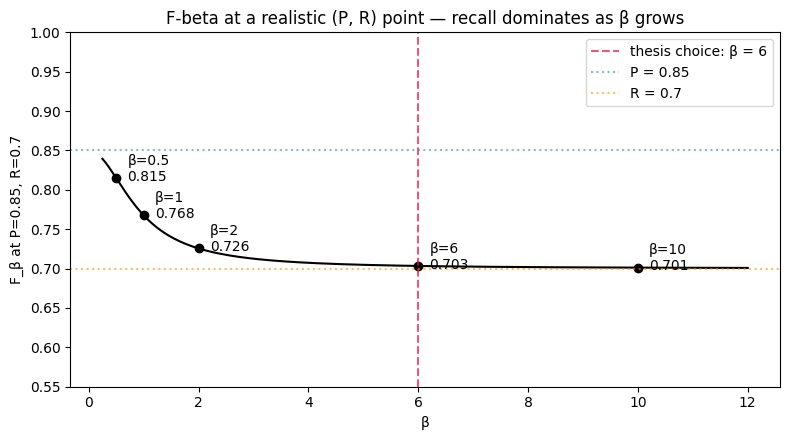

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Smooth curve across continuous β so the points sit on a clear line.
import numpy as np
beta_grid = np.linspace(0.25, 12.0, 200)
ax.plot(beta_grid, [fbeta(P, R, b) for b in beta_grid], color="black")

for b, v in zip(betas, values):
    ax.plot(b, v, "o", color="black")
    ax.annotate(f"β={b:g}\n{v:.3f}", (b, v), textcoords="offset points", xytext=(8, -2))

ax.axvline(6.0, color="crimson", linestyle="--", alpha=0.7, label="thesis choice: β = 6")
ax.axhline(P, color="steelblue", linestyle=":", alpha=0.6, label=f"P = {P}")
ax.axhline(R, color="darkorange", linestyle=":", alpha=0.6, label=f"R = {R}")

ax.set_xlabel("β")
ax.set_ylabel(f"F_β at P={P}, R={R}")
ax.set_title("F-beta at a realistic (P, R) point — recall dominates as β grows")
ax.set_ylim(0.55, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

## (f) Hardness distribution on Spider dev

Reference: published Spider 1.0 dev counts are easy=248, medium=446, hard=174, extra=166. Our vendored port in `utils/difficulty.py` reproduces these exactly — cross-checked in `tests/test_difficulty.py`.

In [10]:
from collections import Counter
counts = Counter(hardness.values())
order = ["easy", "medium", "hard", "extra"]
pd.DataFrame({
    "n_queries": [counts[h] for h in order],
    "share": [counts[h] / len(hardness) for h in order],
}, index=pd.Index(order, name="hardness")).round(4)

,n_queries,share
hardness,,
easy,248,0.2398
medium,446,0.4313
hard,174,0.1683
extra,166,0.1605


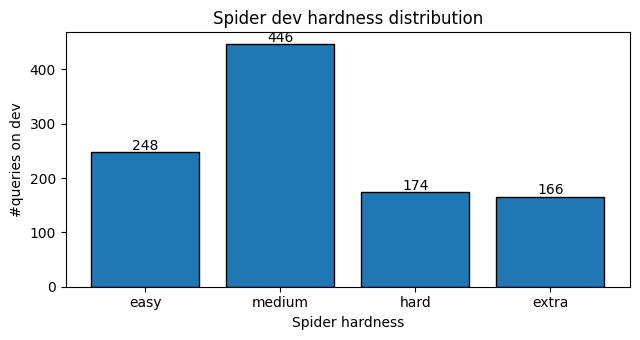

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(order, [counts[h] for h in order], edgecolor="black")
ax.set_xlabel("Spider hardness")
ax.set_ylabel("#queries on dev")
ax.set_title("Spider dev hardness distribution")
for i, h in enumerate(order):
    ax.text(i, counts[h] + 4, str(counts[h]), ha="center")
plt.tight_layout()
plt.show()

## Takeaways

* The evaluator round-trips real gold cleanly (§c).
* The empty-prediction floor (§d) is non-trivial only because some queries have empty gold at the column level (count(*) etc.) — a method that always predicts nothing wouldn't quite score 0 on SRR, but it would score 0 on recall almost everywhere.
* F-beta at β = 6 (§e) is well above F1 for any reasonable (P, R) and visibly favours recall — that's the metric the thesis is going to report alongside F1 (§c, §d) plus SRR. The plot makes the choice defensible at a glance.
* Hardness counts (§f) are the published Spider numbers exactly; the per-hardness breakdown in `notebooks/02_gold_extraction_sanity.ipynb` is built on the same buckets.
